https://github.com/aeon-toolkit/aeon/blob/main/examples/anomaly_detection/anomaly_detection.ipynb



https://www.sktime.net/en/v0.34.0/examples/07_detection_anomaly_changepoints.html

https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html

https://github.com/GeneSUN/Anomaly_Detection_toolkit

https://forecastegy.com/posts/time-series-anomaly-detection-python/

#### Импорт

#### Утилиты 

##### Скачивем, если их нет

In [1]:
import os
if not os.path.exists('utilits4tsc'):
    !git clone --depth 1 https://github.com/MVRonkin/TimeSeriesCourse.git temp_repo
    !mv temp_repo/2026/WS/utilits4tsc .

##### содержание

In [2]:
from utilits4tsc import *
plt_style_GOST()
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
  * [Обнаружение нерегулярного поведения в данных](#обнаружение-нерегулярного-поведения-в-данных)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [5]:
from scipy import stats
# import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm

In [6]:
from pandas.tseries.frequencies import to_offset

In [7]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [8]:
from functools import partial

### Загрузка данных

Импорт данных аналогично предыдущего урока.

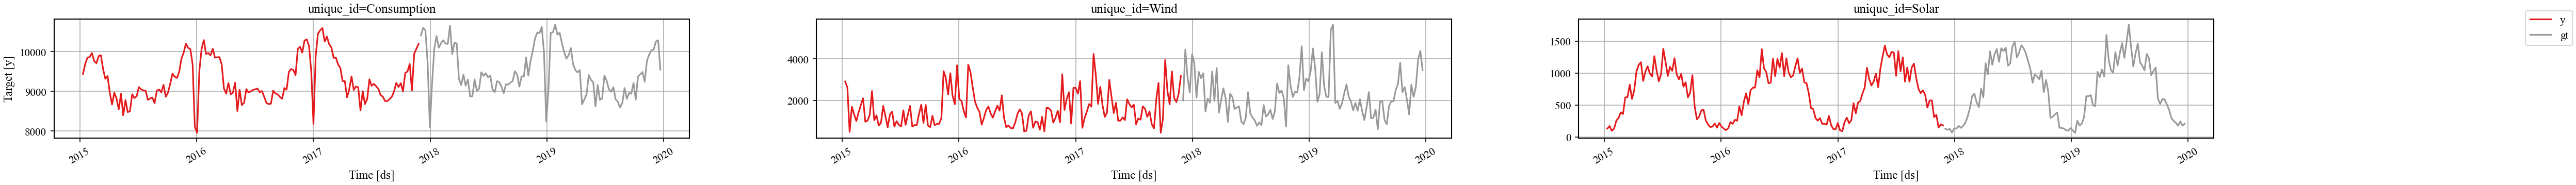

In [9]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [10]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Обнаружение нерегулярного поведения в данных

### Использование вероятностного предсказания для поиска аномалий

Here we identified the anomalies in the data using the MSTL model, but any probabilistic model from StatsForecast can be used. We also selected the 99% prediction interval of the insample forecasts, but other confidence levels can be used as well.

In [11]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

#### выбор уровня доверия к данным 

In [12]:
levels = [99]

#### Выбор модели

In [13]:
models = [MSTL(season_length=[SEASON], alias='MSTL')]
alias = [x.alias for x in models]

#### Обучение модели  in-sample prediction

In [14]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')


#### Выбор и визуализация аномалий
##### Встроенная визуализация аномалий по интервалу перекрытия

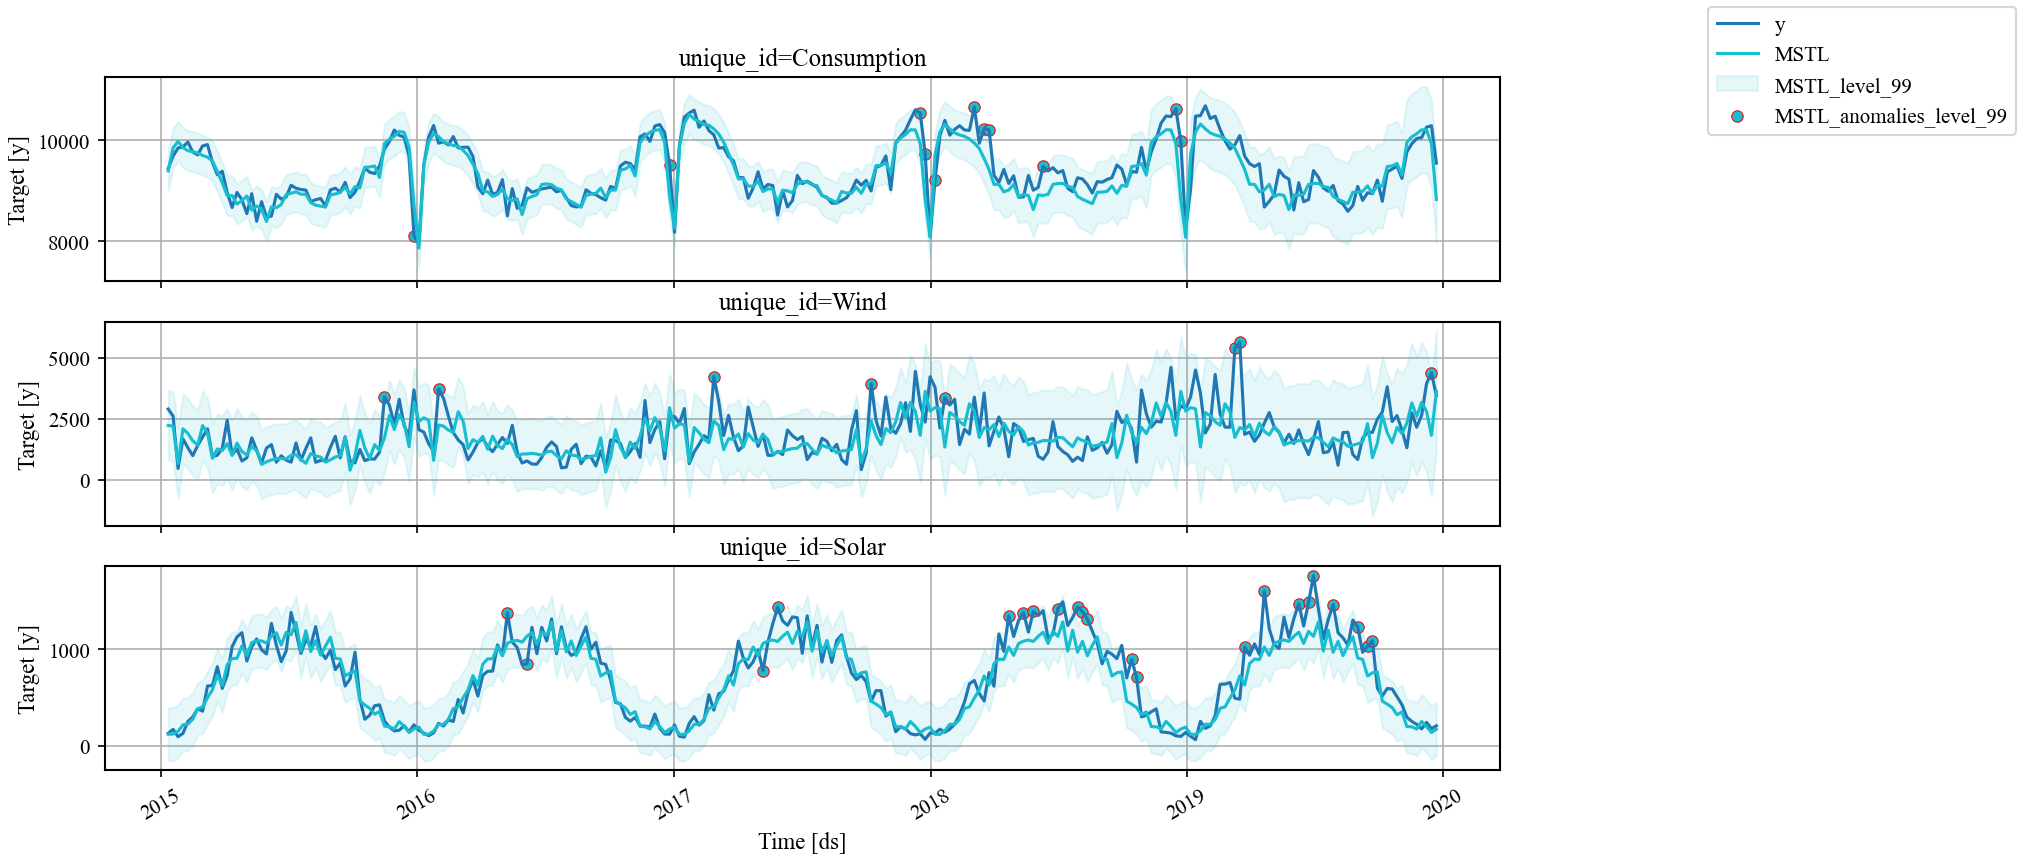

In [15]:
plot_series_v2(forecasts_df=res_df, level=levels, plot_anomalies=True)

##### Визуализация заданных аномалий

In [16]:
anomalies = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])]
anomalies.head()

,unique_id,ds,y,MSTL,MSTL-lo-99,MSTL-hi-99
50,Consumption,2015-12-27,8106.565,8717.428300,8321.652892,9113.203708
102,Consumption,2016-12-25,9513.222,8891.184984,8495.409576,9286.960392
153,Consumption,2017-12-17,10535.852,9931.456661,9520.668407,10342.244915
154,Consumption,2017-12-24,9735.578,8830.469147,8413.014221,9247.924072
156,Consumption,2018-01-07,9216.217,9707.269506,9276.790859,10137.748153


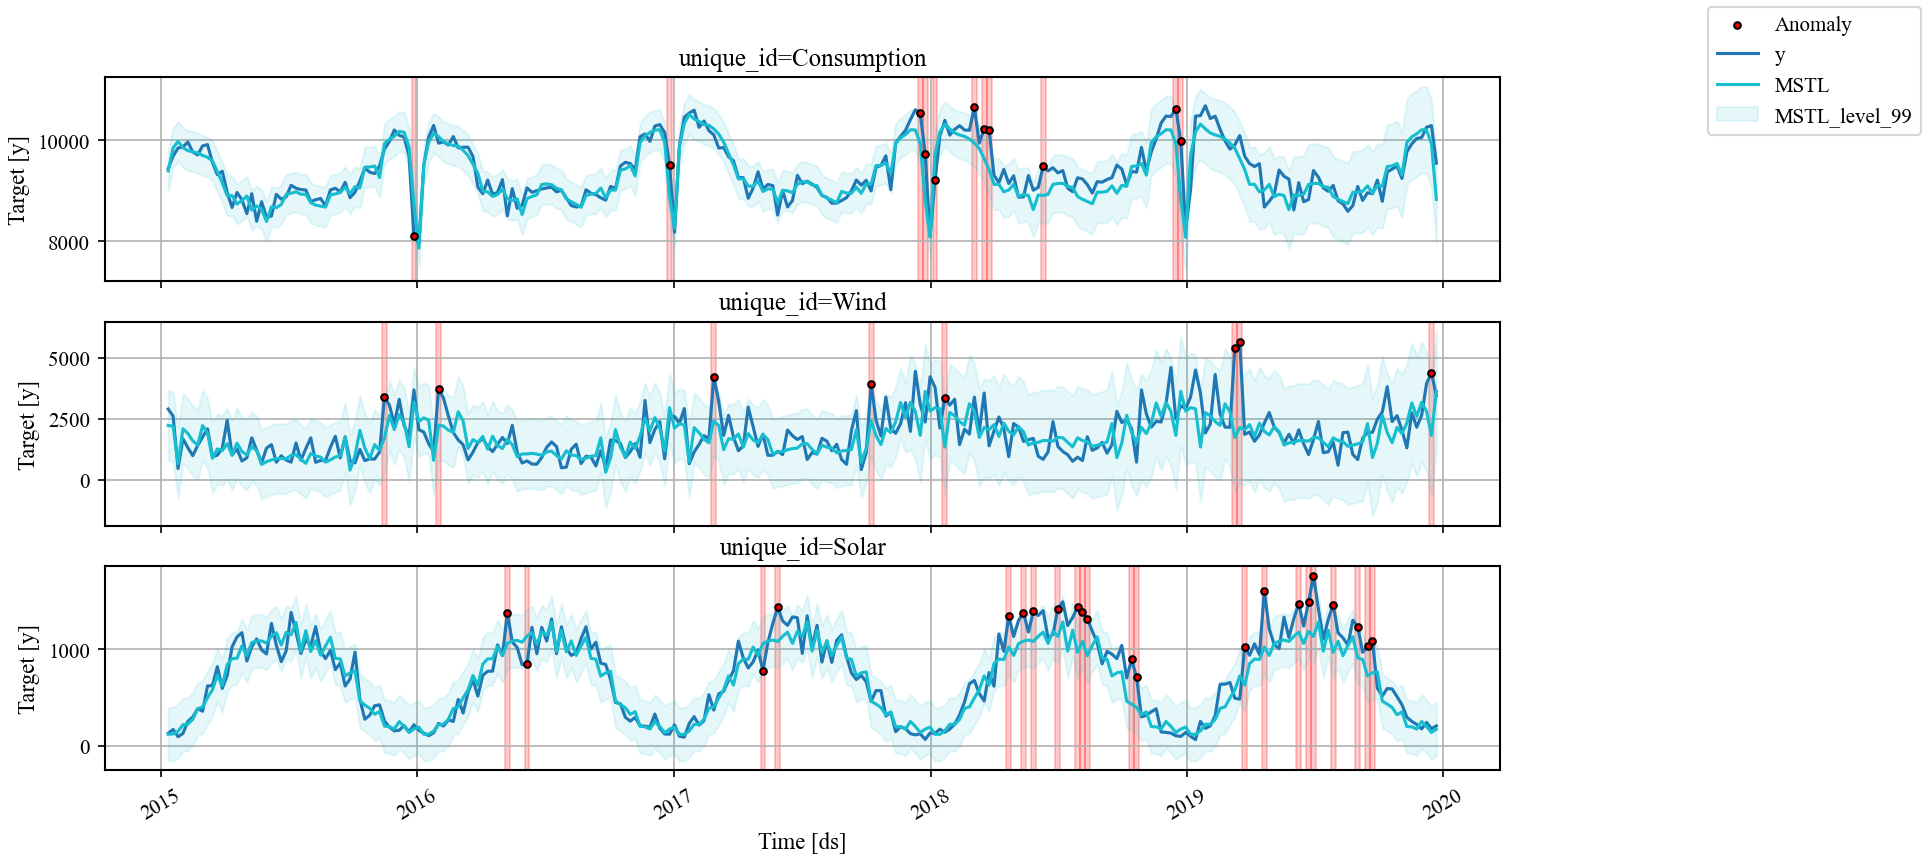

In [17]:
plot_series_v2(forecasts_df=res_df, 
               level=levels, 
               anomalies_df=anomalies,
               marker_size = 10,
               anomaly_width = '1w'  )

#### Аномалии через кросс-валидацию

##### Построим n-step-ahead по удвоенному testsize

In [18]:
level = [99]

In [19]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)
cv_conf = dict(h=FH//4,
           n_windows=7,
           step_size=FH//4,
           fitted = True,
           level = level,    
           refit=True,  )     

cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf)

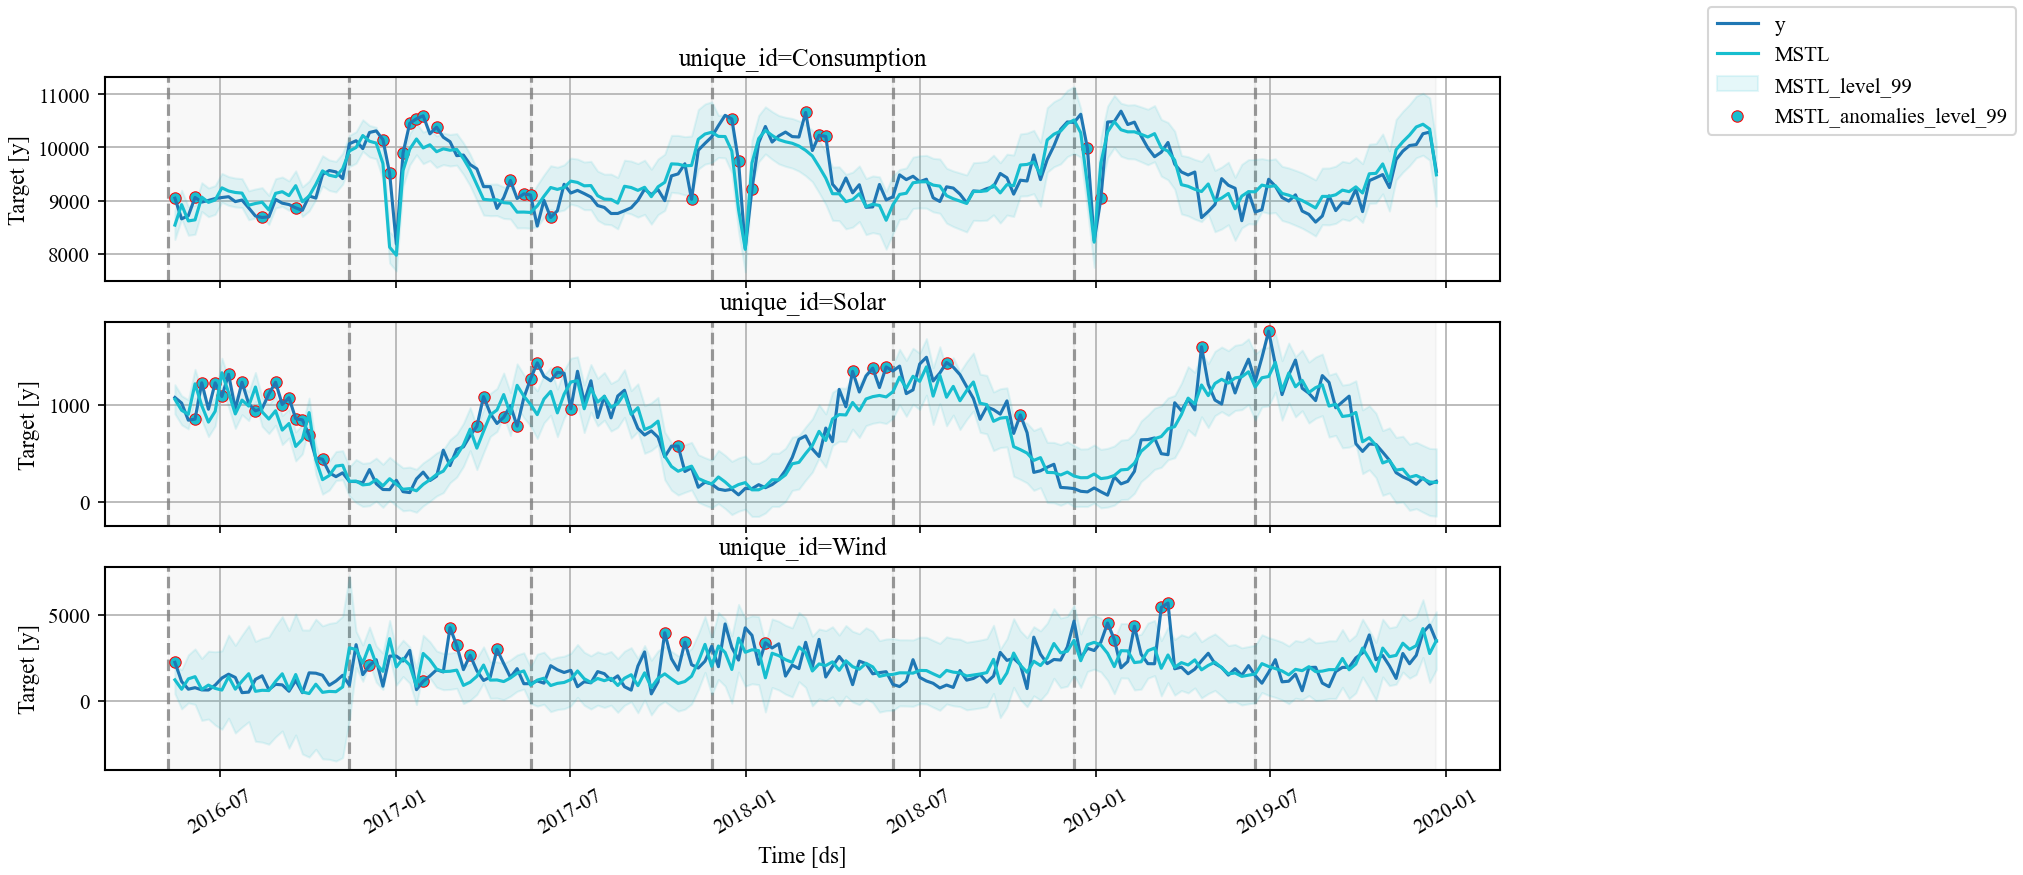

In [20]:
plot_series_v2(forecasts_df=cv_df, level=level, models = alias, plot_anomalies=True, plot_cutoff=True)

#### Оценка метрик на участках CV с аномалиями и без них

##### Посчитаем anomaly_score

In [21]:
# cv_df["anomaly"] = (cv_df["y"] < cv_df[lo] |cv_df["y"] > cv_df[hi])
cv_df["anomaly_score"] = np.maximum(
    cv_df["y"] - cv_df[f"{alias[0]}-hi-{level[0]}"],
    cv_df[f"{alias[0]}-lo-{level[0]}"] - cv_df["y"]
).clip(lower=0)
anomaly_grouped = cv_df.groupby(['unique_id', 'cutoff'])['anomaly_score'].mean()
pd.DataFrame(anomaly_grouped)

anomaly_score
unique_id   cutoff                   
Consumption 2016-05-08      19.967441
            2016-11-13      82.860922
            2017-05-21       8.785950
            2017-11-26      50.570458
            2018-06-03       0.000000
            2018-12-09      15.251037
            2019-06-16       0.000000
Solar       2016-05-08      56.216737
            2016-11-13      14.333973
            2017-05-21      18.775518
            2017-11-26       3.709487
            2018-06-03       4.245722
            2018-12-09       2.453651
            2019-06-16       6.103908
Wind        2016-05-08       7.738450
            2016-11-13     138.527846
            2017-05-21      53.620539
            2017-11-26       1.989183
            2018-06-03       0.000000
            2018-12-09     148.886195
            2019-06-16       0.000000

##### расчет и группировка метрик

In [22]:
eval_df = evaluate(
        cv_df,
        metrics=[mae, coverage],
        level = level,    
        models = alias
    ).pivot(
    index=['unique_id', 'cutoff'], 
    columns='metric', 
    values=alias
).reset_index()
if isinstance(eval_df.columns, pd.MultiIndex):
    eval_df.columns = [f"{metric}" if metric else val for val, metric in eval_df.columns]
eval_df = eval_df.merge(anomaly_grouped, on=['unique_id', 'cutoff'], how='left')
eval_df

,unique_id,cutoff,coverage_level99,mae,anomaly_score
0,Consumption,2016-05-08,0.851852,172.317404,19.967441
1,Consumption,2016-11-13,0.629630,309.471729,82.860922
2,Consumption,2017-05-21,0.925926,225.024221,8.785950
3,Consumption,2017-11-26,0.777778,281.068873,50.570458
4,Consumption,2018-06-03,1.000000,151.905804,0.000000
5,Consumption,2018-12-09,0.925926,266.612972,15.251037
6,Consumption,2019-06-16,1.000000,176.614966,0.000000
7,Solar,2016-05-08,0.444444,162.916758,56.216737
8,Solar,2016-11-13,0.814815,108.252302,14.333973
9,Solar,2017-05-21,0.851852,131.364633,18.775518


Как и ожидалось на участках с самым высоким anomaly_score самые высокие ошибки MAE и худшее покрытие

### Использование Sklearn подходов и интерфейса MLForecast

#### Имопрт OSVM

In [23]:
from mlforecast import MLForecast
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

In [24]:
ocsvm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('ocsvm', OneClassSVM(kernel='rbf', gamma=0.05, nu=0.01)),
])

mlf = MLForecast(
    models={'ocsvm': ocsvm_pipeline},
    freq=FREQ,
    lags=[1, 2, 3, 4, 5 ],
    # target_transforms = Di
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

# Получаем fitted values и предсказания
insample = mlf.forecast_fitted_values().drop(columns=['y'])  # ocsvm выдаёт -1/1, не y_hat
y_hat    = mlf.predict(h = FH,)
res_df   = panel_df.merge(pd.concat([insample,y_hat],), on=['unique_id', 'ds'], how='left')

# # # -1 = аномалия, 1 = норма
anomalies = res_df[res_df['ocsvm'] == -1][['unique_id', 'ds', 'y', 'ocsvm']]
# # anomalies


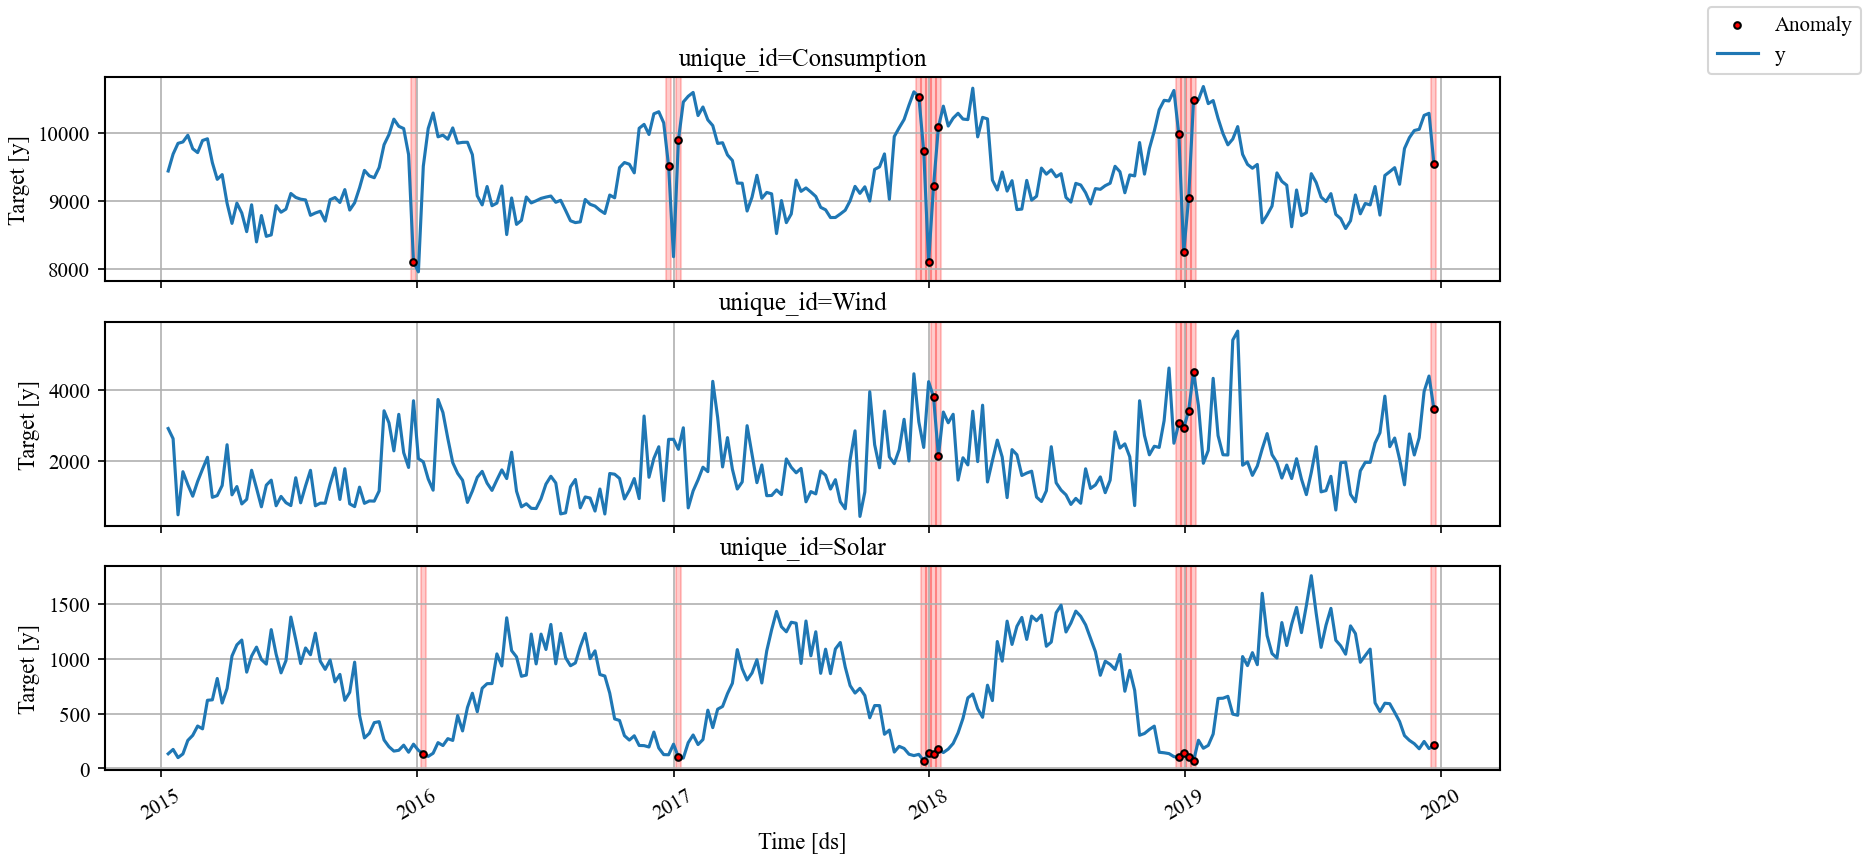

In [25]:
plot_series_v2(forecasts_df=res_df.drop(columns = ['ocsvm']), 
               # level=levels, 
               anomalies_df=anomalies.drop(columns = ['ocsvm']),
               marker_size = 10,
               anomaly_width = '1w'  )

### Использование Unsupervised AD

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN, OPTICS 

In [27]:
models_anomaly = {
    'iforest': Pipeline([
        ('scaler', RobustScaler()),
        ('model', IsolationForest(contamination=0.02,n_estimators = 1000, random_state=0)),
    ]),
    'lof': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LocalOutlierFactor(n_neighbors=5, contamination=0.02, novelty=True)),
    ]), 
}
model_cols = list(models_anomaly.keys())

mlf = MLForecast(
    models=models_anomaly,
    freq=FREQ,
    lags=[1, 2, 3,  ],
    # target_transforms = Di
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

# Получаем fitted values и предсказания
insample = mlf.forecast_fitted_values().drop(columns=['y'])  # ocsvm выдаёт -1/1, не y_hat
y_hat    = mlf.predict(h = FH,)
res_df   = panel_df.merge(pd.concat([insample,y_hat],), on=['unique_id', 'ds'], how='left')


anomalies = res_df[
    (res_df[model_cols] == -1).any(axis=1)
].copy()

In [ ]:
plot_series_v2(forecasts_df=res_df, 
               anomaly_models = model_cols,
               anomalies_df=anomalies,
               marker_size = 10,
               anomaly_width = '1w'  )

### Добавление собественного детектора 

#### детектор основанный на правилах (вдохновлен [ADTK](https://adtk.readthedocs.io/en/stable/))

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import check_classification_targets

class QuantileAD(BaseEstimator, RegressorMixin):
    """
    Обнаружение аномалий на основе квантилей.
    Если значение выходит за пределы [low, high] квантилей, оно считается аномалией.
    """
    def __init__(self, low=None, high=None):
        self.low = low
        self.high = high
    def fit(self, X, y):
        # Проверка входных данных. X может быть пустым (dummy), y должен быть 1D массивом.
        # allow_nd=True позволяет передавать X как 2D массив, даже если мы используем только y.
        X, y = check_X_y(X, y, y_numeric=True, ensure_2d=True)        
        y_arr = np.asarray(y)        
        # Вычисляем границы
        self.abs_low_ = np.quantile(y_arr, self.low) if self.low is not None else -np.inf
        self.abs_high_ = np.quantile(y_arr, self.high) if self.high is not None else np.inf        
        # Сохраняем количество признаков для проверки в predict
        self.n_features_in_ = X.shape[1]        
        return self

    def predict(self, X):
        # Проверяем, был ли вызван fit
        check_is_fitted(self)
        # Проверяем входные данные
        X = check_array(X, ensure_2d=True)        
        # Проверка на соответствие размерности (если обучались на X с n фичами, ожидаем n)
        if X.shape[1] != self.n_features_in_:
             raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        # Используем первый столбец как значение ряда (lag1)
        y_arr = X[:, 0]
        return np.where((y_arr > self.abs_high_) | (y_arr < self.abs_low_), -1.0, 1.0)

In [ ]:
models = {
    'QuantileAD': QuantileAD(low=0.1, high=0.99),    
}

In [ ]:
mlf = MLForecast(
    models=models,
    freq=FREQ,
    lags=list(range(1,SEASON//4)),
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

insample = mlf.forecast_fitted_values().drop(columns=['y'])
res_df   = panel_df.merge(insample, on=['unique_id', 'ds'], how='left')

model_cols   = list(models.keys())
anomalies = res_df[
    (res_df[model_cols] == -1).any(axis=1)
].copy()


plot_series_v3(forecasts_df=res_df, 
               anomaly_models = model_cols,
               anomalies_df=anomalies,
               marker_size = 10,
               anomaly_width = '1w'  )

### Профилирование временного ряда

#### Понятие профиля ВР

[Matrix Profile](https://github.com/stumpy-dev/stumpy/blob/main/paper/paper.md) - метод, заключающийся в сравнении всех попарных расстояний между каждой подпоследовательностью во временном ряду (т.е. объединение по принципу самоподобия. Метод позволяет находить:
 - мотивы (повторяющиеся паттерны) 
  - диссонансы (редкие паттерны)

Метод вовзращает 2 выхода:
- profile_score это матричный профиль - то есть вектор, представляющий расстояния между всеми подпоследовательностями во временном ряду и их ближайшими соседями
    - Пики профиля: Это аномалии или уникальные паттерны. В этом месте расстояние до ближайшего похожего паттерна максимально. То есть этот участок ряда ни на что не похож.
    - Низины профиля: Это часто повторяющиеся, "нормальные" паттерны.
- profile_index (сосед) подсказывает, на что была похожа эта аномалия (иногда аномалия — это просто повтор редкого паттерна). profile_index может быть и двойным (справа и слева).

 

#### Формирование профиля

In [31]:
import stumpy
import numpy as np

In [63]:
profile_results = []
window_size = 52 

for uid_name, uid_df in panel_df.groupby('unique_id'):
    # 1. Подготовка данных
    ts_values = uid_df['y'].values.astype(np.float64)
    dates = uid_df['ds'].values

    # 2. Вычисляем Matrix Profile
    mp = stumpy.stump(ts_values, m=window_size)
    
    # 3. Формируем DataFrame результатов
    # Matrix Profile сдвинут на (window_size - 1) точек
    start_idx = window_size - 1

    # сборка
    res_df = pd.DataFrame({
        'unique_id' : uid_name,        
        'ds': dates[start_idx:],
        'y': ts_values[start_idx:] ,
        'profile_score': mp[:, 0], # 0-я колонка - расстояние (score)
        'profile_index': mp[:, 1],  # 1-я колонка - индекс ближайшего соседа
    })

    profile_results.append(res_df)

# Объединяем всё в один long-DataFrame
profile_results = pd.concat(profile_results, ignore_index=True)
profile_results.head(2)

,unique_id,ds,y,profile_score,profile_index
0,Consumption,2016-01-03,7957.158,3.668758,157
1,Consumption,2016-01-10,9511.344,3.665657,106


#### Поиск топ-10 аномалий ВР (диссонансы)
Могут быть и другие способы анализа профиля.

In [61]:
top_n=10
results = []    
for uid, df in profile_results.groupby('unique_id'):
    df = df.copy().reset_index(drop=True)
    scores = df['profile_score'].values
    threshold_val = np.sort(scores)[-top_n]
    df['is_anomaly'] = scores >= threshold_val        
    results.append(df)

anomalies_df = pd.concat(results, ignore_index=True)


##### Визуализация профиля и диссонансов

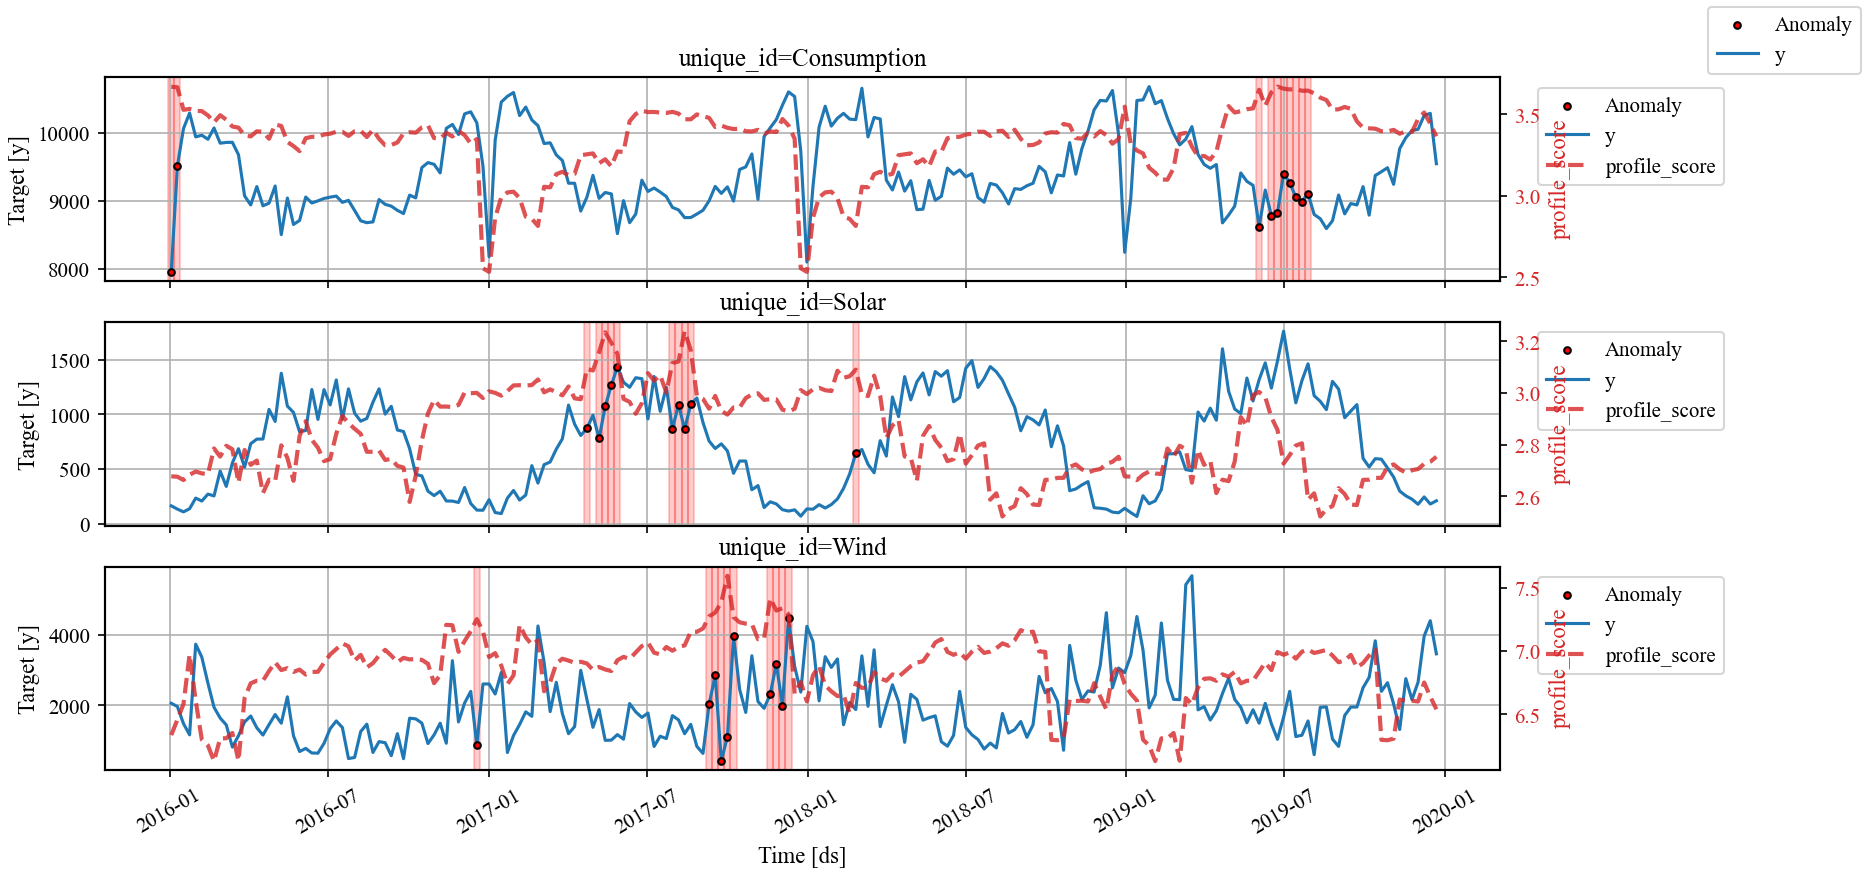

In [62]:
plot_series_v2(forecasts_df=profile_results.drop(columns=['profile_index']), 
               anomalies_df = anomalies_df[anomalies_df['is_anomaly']],
               second_axis='profile_score',
               marker_size = 10,
               anomaly_width = '1w',
          )

In [70]:
from aeon.anomaly_detection.series.distance_based import ROCKAD
import numpy as np
import pandas as pd

profile_results = []
# Максимально возможное окно
max_window_size = 52 

for uid_name, uid_df in panel_df.groupby('unique_id'):
    # 1. Подготовка данных
    ts_values = uid_df['y'].values.astype(np.float64)
    dates = uid_df['ds'].values
    
    # --- ПРОВЕРКА ДЛИНЫ РЯДА ---
    # Длина ряда должна быть как минимум равна окну (а лучше больше)
    n_samples = len(ts_values)
    
    if n_samples < 5: # Если ряд совсем короткий, пропускаем
        print(f"Skipping {uid_name}: too short ({n_samples} points)")
        continue
        
    # Подбираем окно: берем минимум из желаемого и реального размера ряда
    # Например, если в ряду 30 точек, окно будет 30. Если 100 — окно будет 52.
    current_window = min(max_window_size, n_samples)
    
    # 2. Инициализация и применение ROCKAD
    # ROCKAD ожидает 2D массив (samples, features)
    X = ts_values

    # Инициализируем модель с текущим безопасным окном
    model = ROCKAD(window_size=current_window, n_estimators=100)
    

    # Получаем оценки аномальности
    scores = model.fit_predict(X)
    
    # 3. Формируем DataFrame результатов
    # Сдвигаем индексы на (window_size - 1), чтобы совместить с датами
    start_idx = current_window - 1

    res_df = pd.DataFrame({
        'unique_id' : uid_name,        
        'ds': dates[start_idx:],           
        'y': ts_values[start_idx:] ,       
        'profile_score': scores[start_idx:], 
    })

    profile_results.append(res_df)

profile_results = pd.concat(profile_results, ignore_index=True)
display(profile_results.head())


,unique_id,ds,y,profile_score
0,Consumption,2016-01-03,7957.158,0.108365
1,Consumption,2016-01-10,9511.344,0.100804
2,Consumption,2016-01-17,10065.537,0.101883
3,Consumption,2016-01-24,10292.945,0.099718
4,Consumption,2016-01-31,9943.095,0.103921


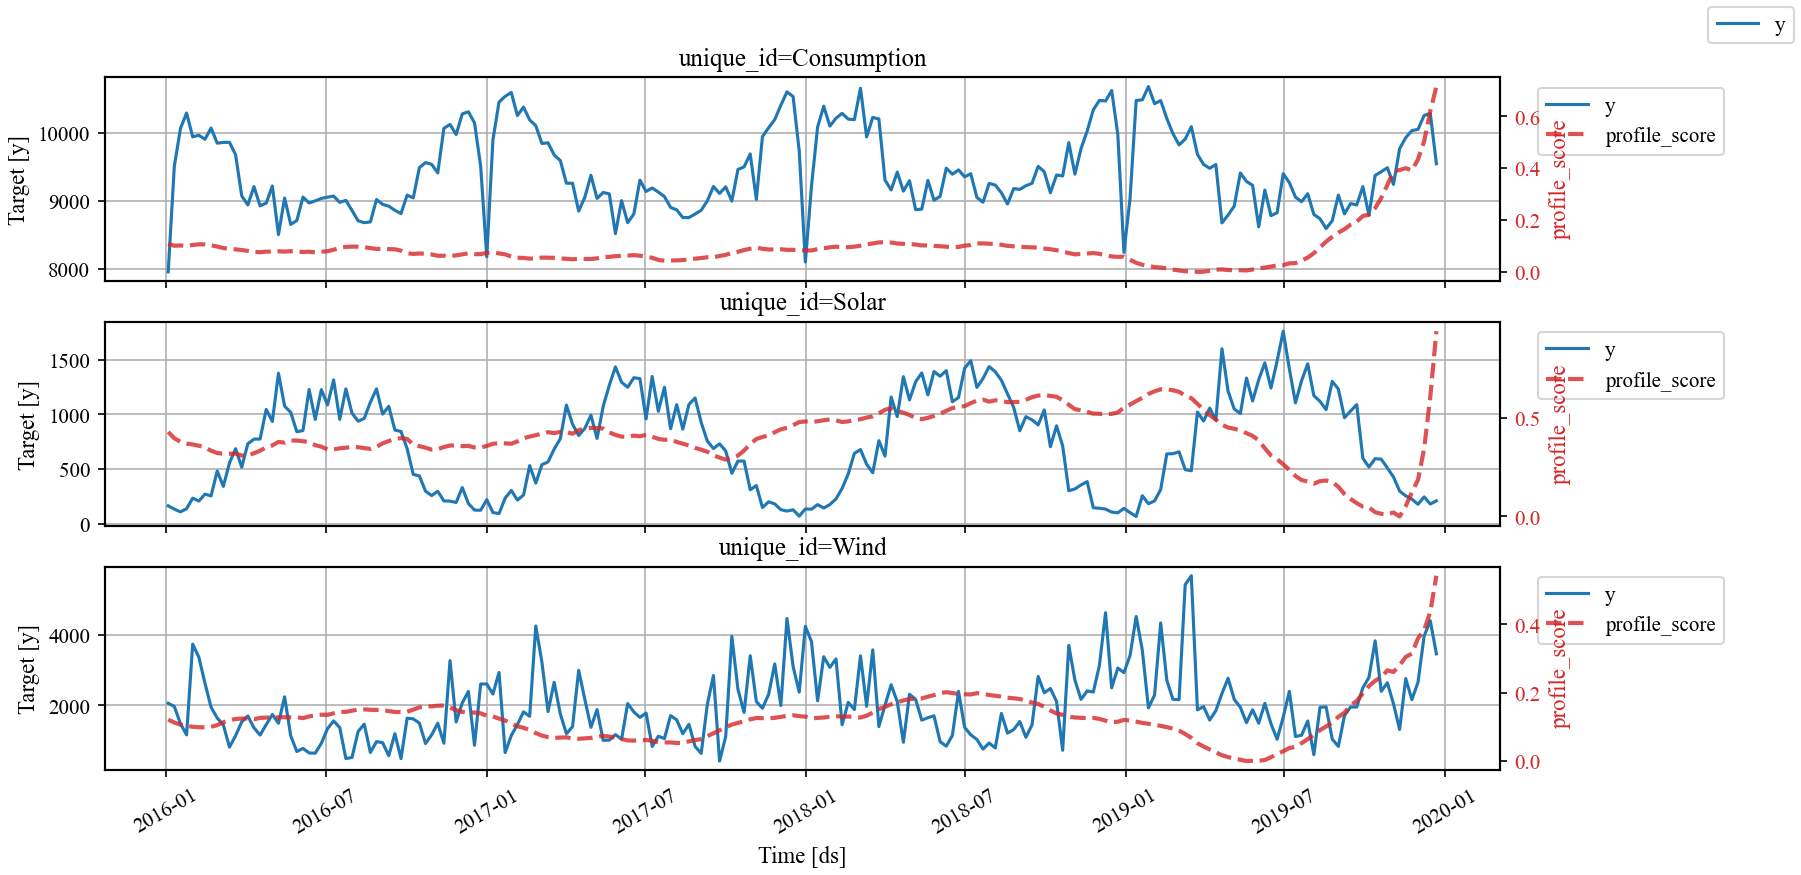

In [72]:
plot_series_v2(forecasts_df=profile_results, 
               # anomalies_df = anomalies_df[anomalies_df['is_anomaly']],
               second_axis='profile_score',
               marker_size = 10,
               anomaly_width = '1w',
          )

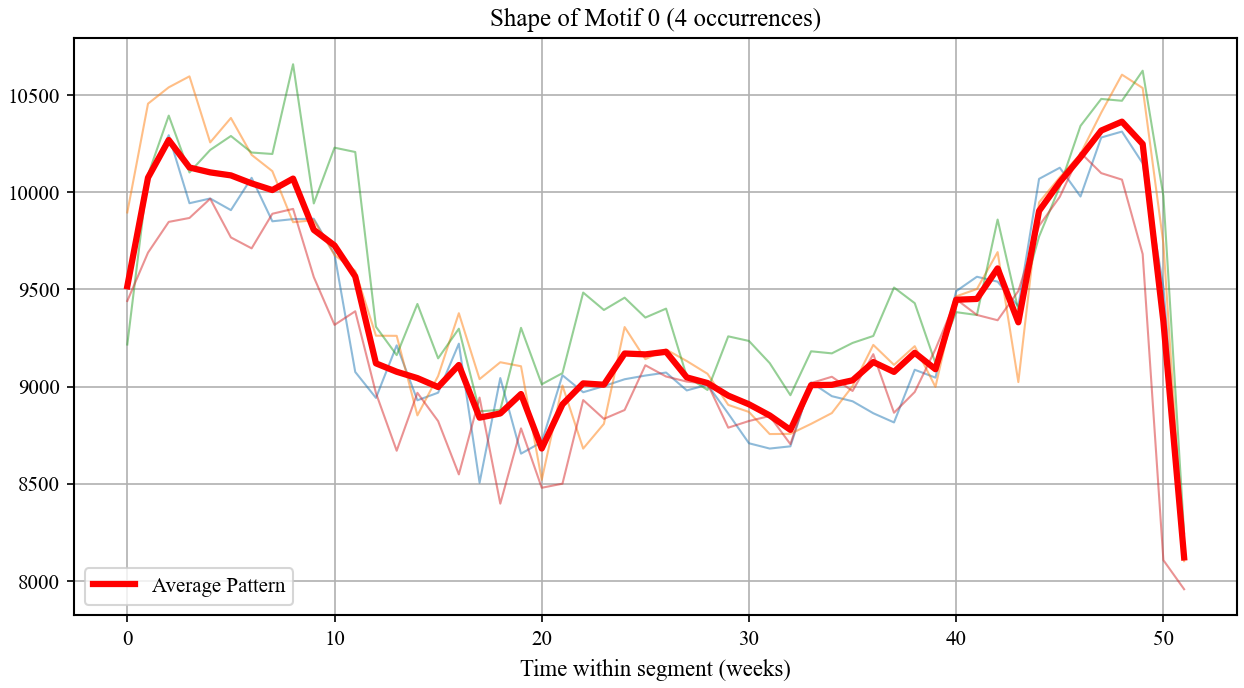

In [254]:
# Выберем первый мотив (самый яркий)
motif_id = 0
indices = motif_indices[motif_id]

plt.figure(figsize=(10, 5))

# Рисуем каждый экземпляр мотива отдельно
for idx in indices:
    # Вырезаем кусок ряда: [start : start + m]
    segment = y_values[idx : idx + window_size]
    plt.plot(range(window_size), segment, lw=1, alpha=0.5)

# Рисуем среднее (усредненная форма мотива)
if len(indices) > 1:
    all_segments = [y_values[idx : idx + window_size] for idx in indices]
    mean_segment = np.mean(all_segments, axis=0)
    plt.plot(range(window_size), mean_segment, color='red', lw=3, label='Average Pattern')

plt.title(f'Shape of Motif {motif_id} ({len(indices)} occurrences)')
plt.xlabel('Time within segment (weeks)')
plt.legend()
plt.show()

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\stumpy\motifs.py:386: UserWarning: No motifs were found. You may consider increasing the `cutoff` (e.g., cutoff=inf) and/or increasing the `max_distance `(e.g., max_distance=np.inf).
  warnings.warn(msg)
C:\Users\Ronkin\AppData\Local\Temp\ipykernel_45696\2163381074.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_shape.legend(loc='upper right', fontsize='small')


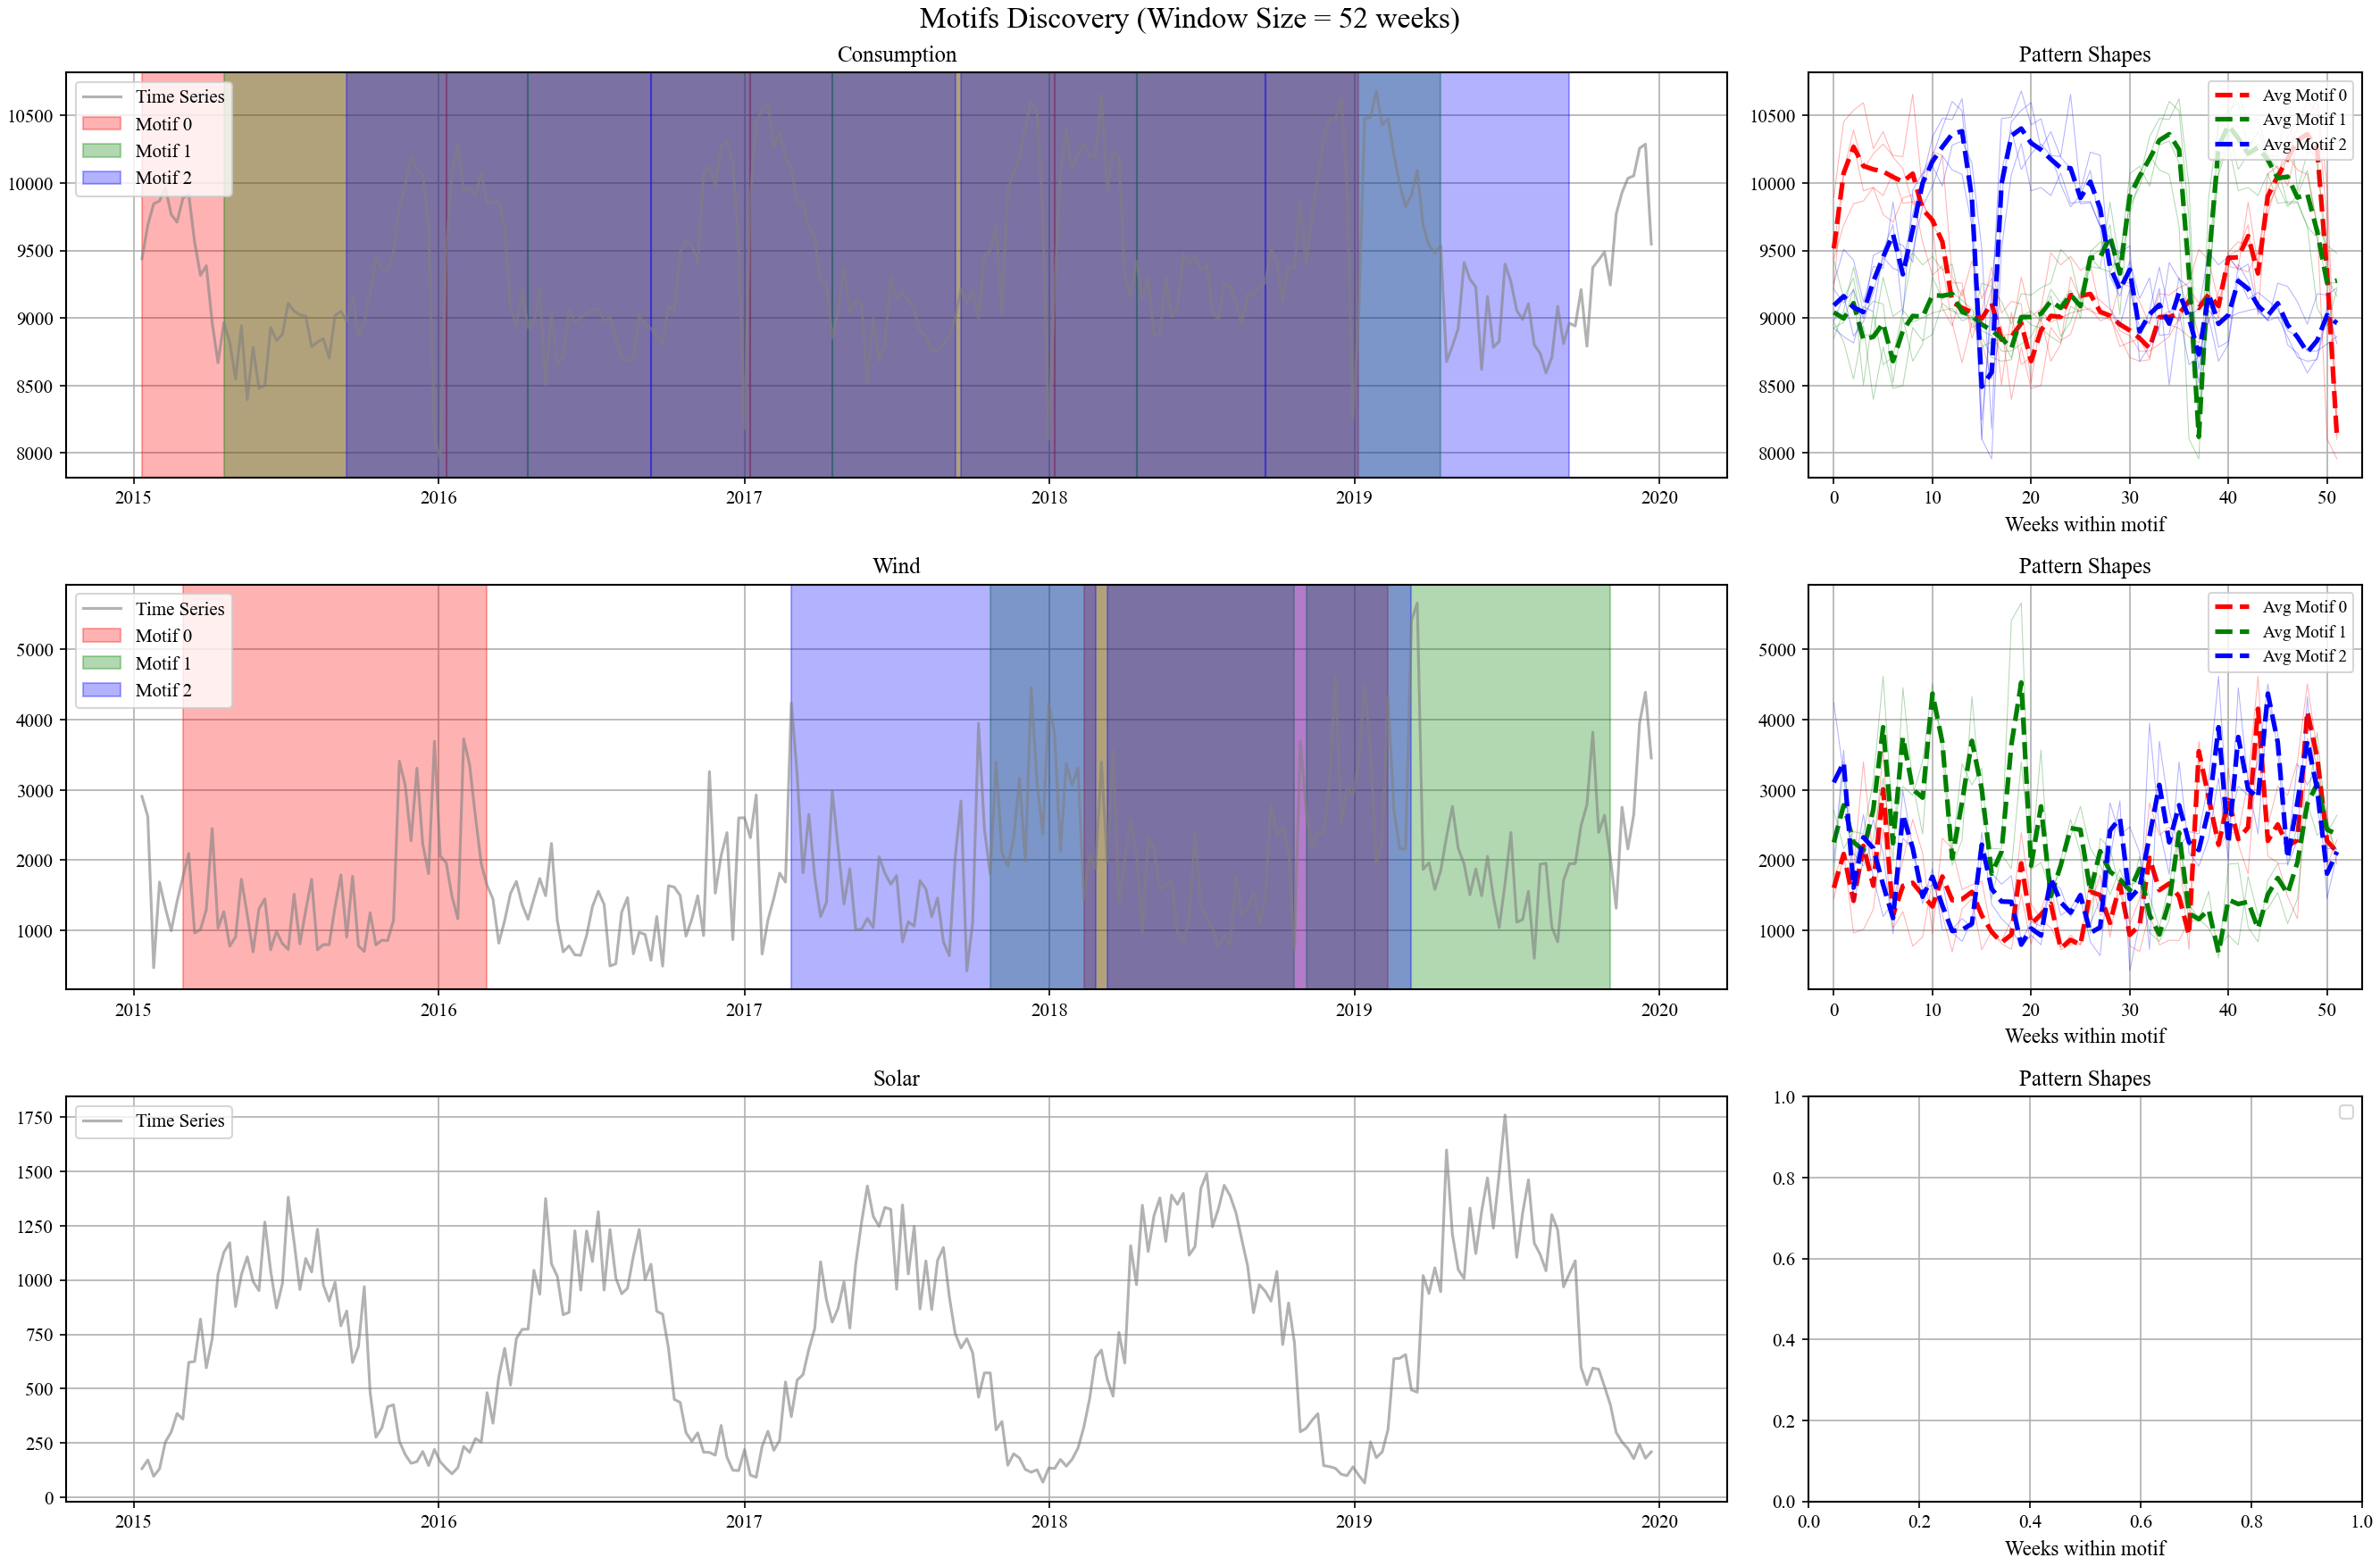

In [255]:
import stumpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Настройки
window_size = 52       # Длина искомого паттерна (год)
max_motifs = 3         # Сколько разных типов паттернов искать (топ-3)
colors = ['red', 'green', 'blue'] # Цвета для разных мотивов

# Готовим фигуру: 3 ряда (по кол-ву переменных) и 2 колонки (Ряд / Форма)
unique_ids = panel_df['unique_id'].unique()
fig, axs = plt.subplots(len(unique_ids), 2, figsize=(18, 12), gridspec_kw={'width_ratios': [3, 1]})

fig.suptitle(f'Motifs Discovery (Window Size = {window_size} weeks)', fontsize=16)

for i, uid in enumerate(unique_ids):
    # 1. Подготовка данных
    df_uid = panel_df[panel_df['unique_id'] == uid].reset_index(drop=True)
    y_values = df_uid['y'].values
    dates = df_uid['ds'].values
    
    # Проверка длины
    if len(y_values) < window_size: continue

    # 2. Вычисление Matrix Profile
    mp = stumpy.stump(y_values, m=window_size)
    
    # 3. Поиск мотивов
    # cutoff=np.inf заставляет искать просто топ-N лучших, не фильтруя по порогу
    try:
        motif_distances, motif_indices = stumpy.motifs(
            y_values, 
            mp[:, 0], 
            max_motifs=max_motifs,
            cutoff=np.inf 
        )
    except Exception:
        continue

    # --- График 1: Временной ряд с подсветкой (левая колонка) ---
    ax_ts = axs[i, 0]
    ax_ts.plot(dates, y_values, color='gray', alpha=0.6, label='Time Series')
    
    # Рисуем полосы для каждого найденного мотива
    for motif_id, indices in enumerate(motif_indices):
        for start_idx in indices:
            end_idx = start_idx + window_size
            ax_ts.axvspan(dates[start_idx], dates[end_idx], 
                          color=colors[motif_id % len(colors)], alpha=0.3, 
                          label=f'Motif {motif_id}' if start_idx == indices[0] else "")
    
    ax_ts.set_title(f'{uid}')
    ax_ts.legend(loc='upper left')

    # --- График 2: Форма паттернов (правая колонка) ---
    ax_shape = axs[i, 1]
    
    for motif_id, indices in enumerate(motif_indices):
        # Рисуем все экземпляры этого мотива полупрозрачными линиями
        for idx in indices:
            segment = y_values[idx : idx + window_size]
            ax_shape.plot(range(window_size), segment, 
                          color=colors[motif_id % len(colors)], alpha=0.3, lw=0.5)
        
        # Рисуем жирную линию среднего (типичная форма)
        # Собираем все сегменты этого мотива
        all_segments = [y_values[idx : idx + window_size] for idx in indices]
        if all_segments:
            mean_segment = np.mean(all_segments, axis=0)
            ax_shape.plot(range(window_size), mean_segment, 
                          color=colors[motif_id % len(colors)], lw=2.5, linestyle='--',
                          label=f'Avg Motif {motif_id}')
            
    ax_shape.set_title('Pattern Shapes')
    ax_shape.legend(loc='upper right', fontsize='small')
    ax_shape.set_xlabel('Weeks within motif')

plt.tight_layout()
plt.show()

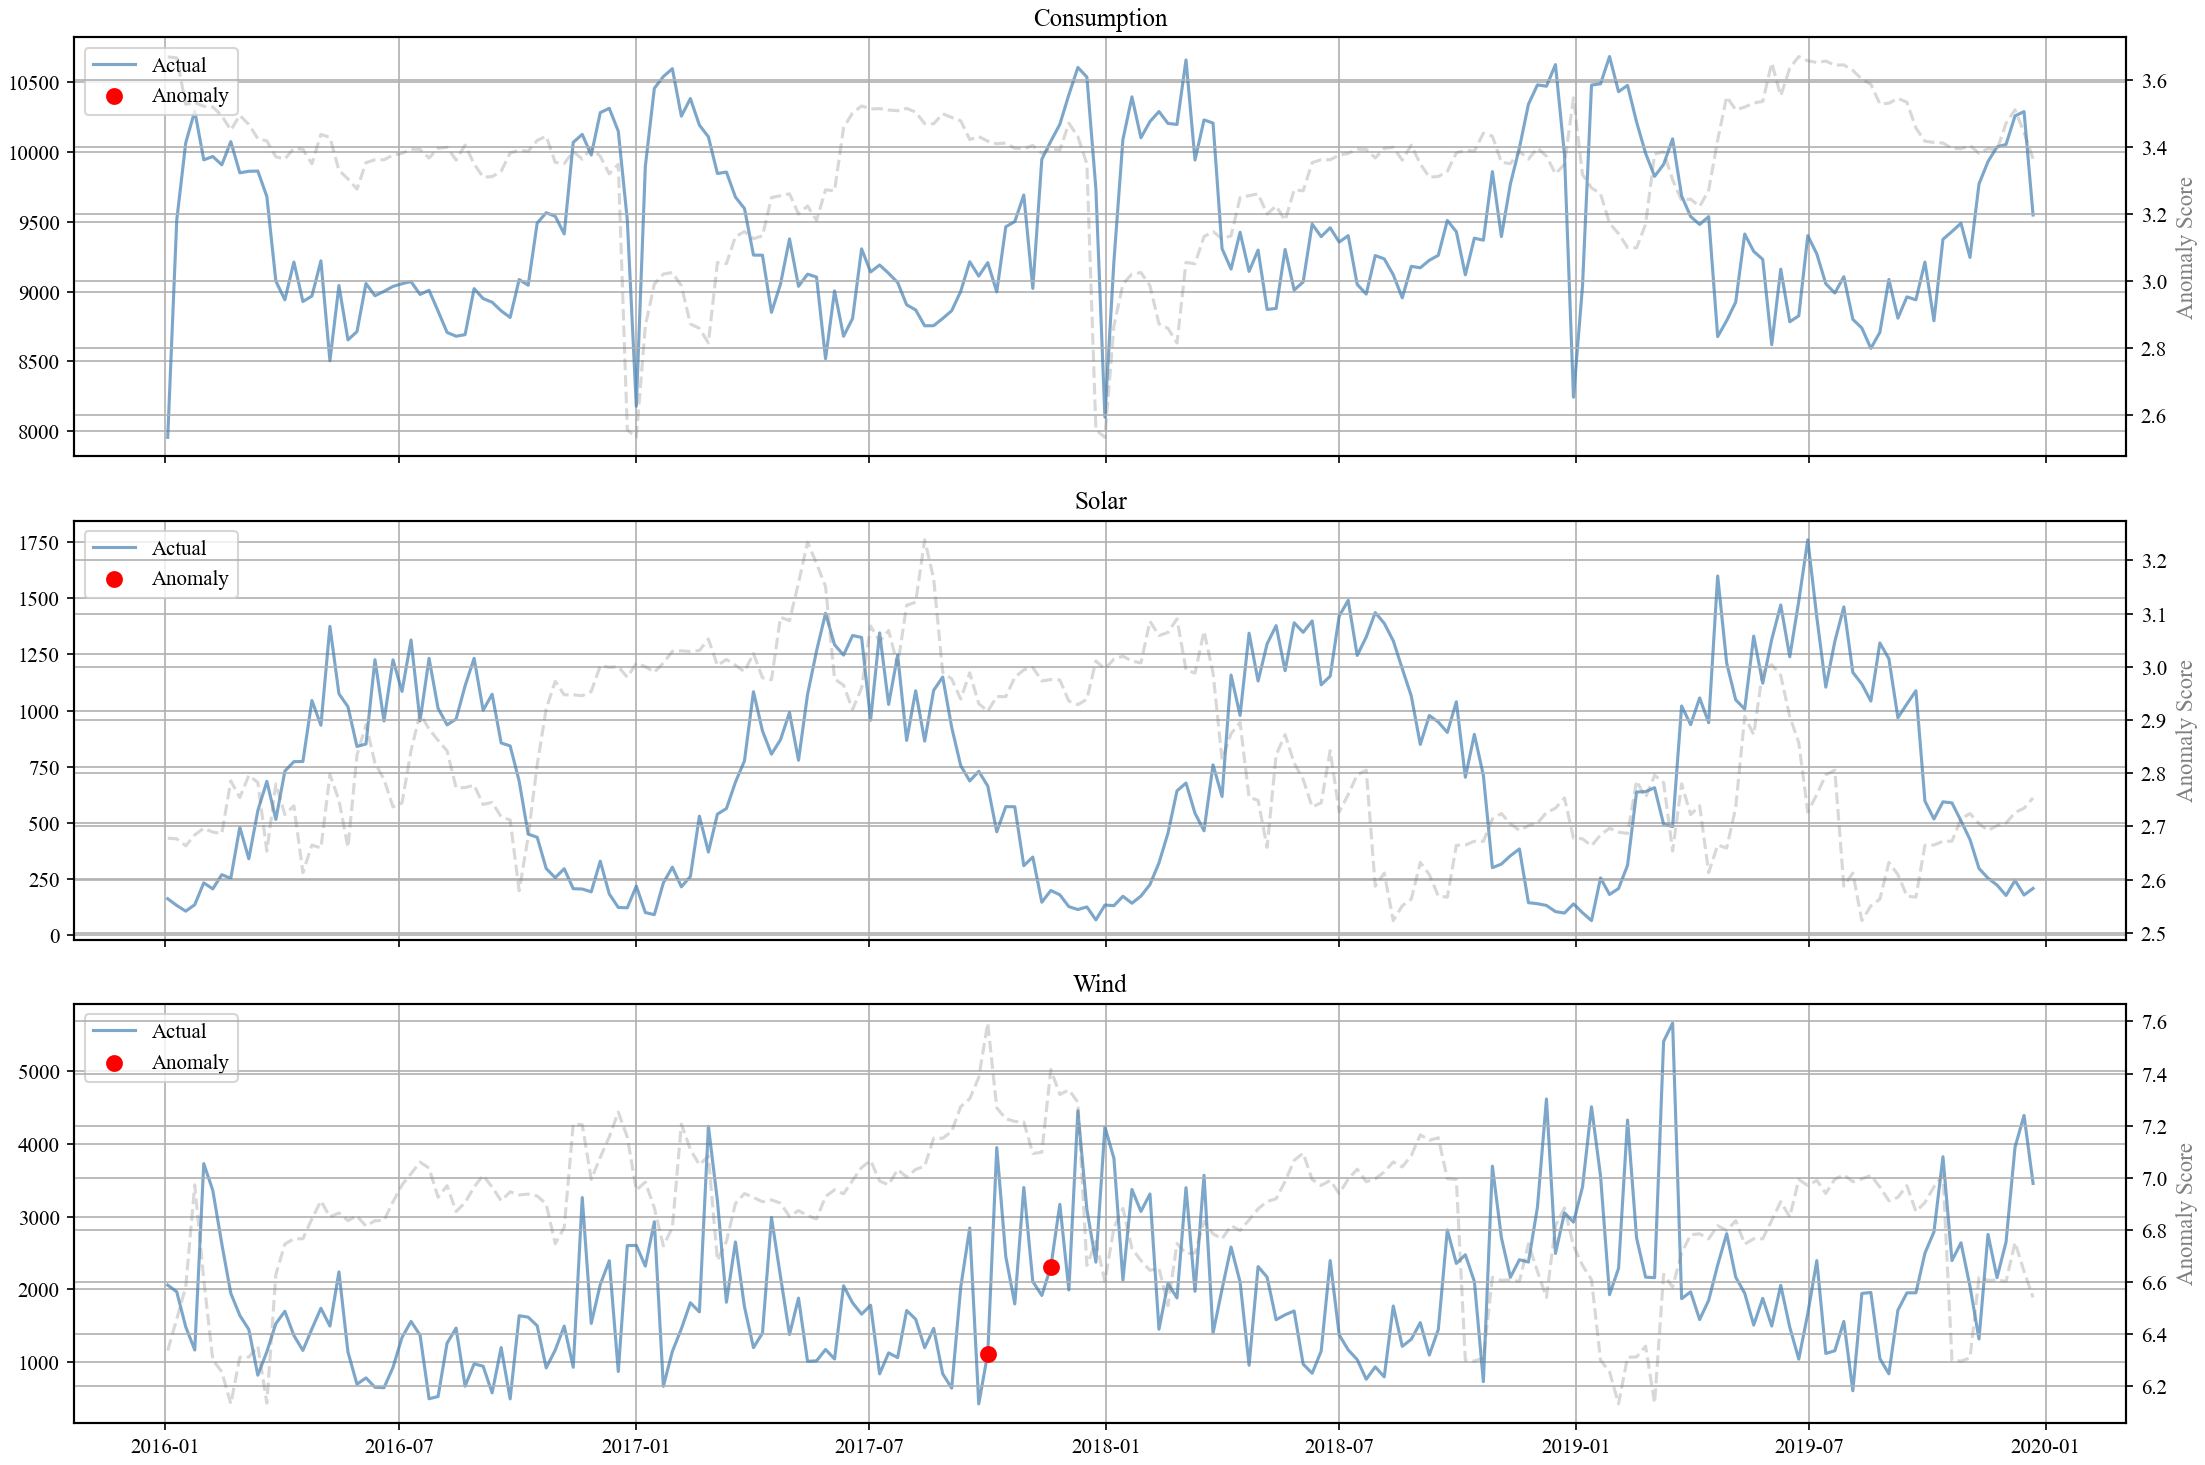

In [233]:
def plot_anomalies(df_anomalies):
    unique_ids = df_anomalies['unique_id'].unique()
    
    fig, axs = plt.subplots(len(unique_ids), 1, figsize=(15, 10), sharex=True)
    
    for i, uid in enumerate(unique_ids):
        ax = axs[i]
        data = df_anomalies[df_anomalies['unique_id'] == uid]
        
        # Рисуем исходный ряд
        ax.plot(data['ds'], data['y'], label='Actual', color='steelblue', alpha=0.7)
        
        # Рисуем Score на второй оси (для понимания, почему сработало)
        ax2 = ax.twinx()
        ax2.plot(data['ds'], data['anomaly_score'], color='gray', alpha=0.3, linestyle='--', label='Score')
        ax2.set_ylabel('Anomaly Score', color='gray')
        
        # Подсвечиваем аномалии
        anomalies = data[data['is_anomaly'] == 1]
        ax.scatter(anomalies['ds'], anomalies['y'], color='red', label='Anomaly', zorder=5, s=50)
        
        ax.set_title(f'{uid}')
        ax.legend(loc='upper left')
        
    plt.tight_layout()
    plt.show()

plot_anomalies(df_anomalies)